# 5.2 합성곱 신경망 맛보기

* Fashion_mnist 데이터셋 사용

In [61]:
%pip install numpy matplotlib torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms #데이터 전처리 위해 사용
from torch.utils.data import Dataset, DataLoader

In [63]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

```python
#하나의 GPU 사용
device = torch.device("cuda:o" if torch.cuda.is_available() else "cpu)
model = Net()
model.to(device)
#다수의 GPU 사용 - nn.DataParallel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch,cuda.device_count() > 1:
  model = nn.DataParallel(net)
  model.to(device)
```

In [64]:
train_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                                 transform=transforms.ToTensor())
#훈련 데이터셋 내려받음
test_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                                 train=False, transform=transforms.Compose([transforms.ToTensor()]))
#테스트 데이터셋 내려받음

In [65]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=100)

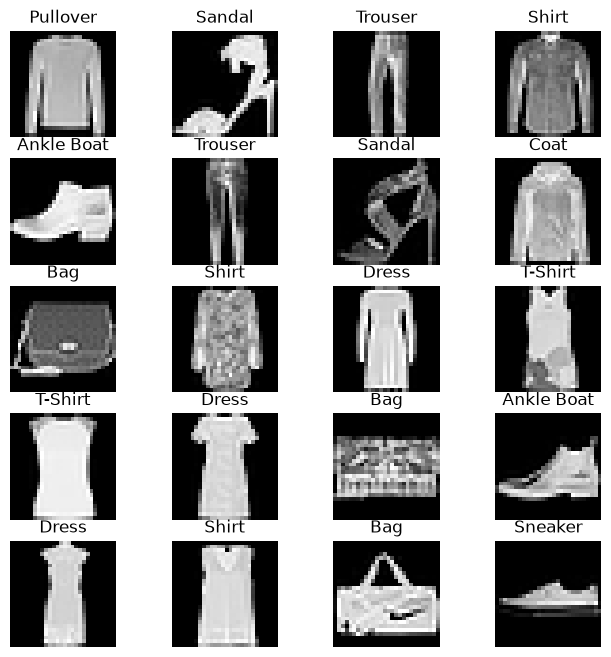

In [66]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress',
             4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker',
             8 : 'Bag', 9 : 'Ankle Boat'}
fig = plt.figure(figsize=(8,8)); #출력할 이미지의 가로세로 길이(단위 inch)
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset));
    img = train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show() #20개의 이미지 데이터를 시작적으로 표현

In [2]:
import numpy as np
np.random.randint(10) #0~10 임의의 숫자 출력

4

In [68]:
np.random.randint(1,10) #1~9 임의의 숫자 출력

2

In [69]:
np.random.rand(8) #0~1 사이의 정규표준분포 난수를 행렬로(1x8) 출력

array([0.95771009, 0.86741595, 0.09033055, 0.13901714, 0.66194825,
       0.35893066, 0.43148298, 0.55712228])

In [70]:
np.random.rand(4,2) #0~1 사이의 정규표준분포 난수를 행렬로 (4X2) 출력

array([[0.99861262, 0.96024919],
       [0.35082775, 0.50579098],
       [0.13346189, 0.44339485],
       [0.65029989, 0.95794197]])

In [3]:
np.random.randn(8) #평균 0, 표준편차 1인 가우시안 정규분포 난수를 행렬로 (1X8) 출력

array([-0.17018413,  1.01947166,  0.6189273 ,  0.87355495,  1.23894227,
       -0.1595063 ,  0.3137377 ,  1.57086668])

In [72]:
np.random.randn(4,2) #평균 0, 표준편차 1인 가우시안 정규분포 난수를 행렬로 (4X2) 출력

array([[ 1.2649086 ,  1.10515144],
       [-0.60666004, -0.39739663],
       [ 0.10290762, -1.15252967],
       [ 0.43877425, -0.24327133]])

* 배열에 대한 사용 예시

In [73]:
import numpy as np
examp = np.arange(0,100,3) #1~99숫자에서 3씩 건너뛴 행렬 생성
examp.resize(6,4) #행렬 크기 6x4로 조정
examp

array([[ 0,  3,  6,  9],
       [12, 15, 18, 21],
       [24, 27, 30, 33],
       [36, 39, 42, 45],
       [48, 51, 54, 57],
       [60, 63, 66, 69]])

In [74]:
examp[3] #3행

array([36, 39, 42, 45])

In [75]:
examp[3,3] #3행 3번째 열 요소

np.int64(45)

In [76]:
examp[3][3] #3행 3번째 열 요소

np.int64(45)

* -> train_dataset[img_xy][0][0,:,:] 의미 

In [77]:
examp = np.arange(0,500,3)
examp.resize(3,5,5)
examp

array([[[  0,   3,   6,   9,  12],
        [ 15,  18,  21,  24,  27],
        [ 30,  33,  36,  39,  42],
        [ 45,  48,  51,  54,  57],
        [ 60,  63,  66,  69,  72]],

       [[ 75,  78,  81,  84,  87],
        [ 90,  93,  96,  99, 102],
        [105, 108, 111, 114, 117],
        [120, 123, 126, 129, 132],
        [135, 138, 141, 144, 147]],

       [[150, 153, 156, 159, 162],
        [165, 168, 171, 174, 177],
        [180, 183, 186, 189, 192],
        [195, 198, 201, 204, 207],
        [210, 213, 216, 219, 222]]])

In [78]:
examp[2][0][3]
#이 것과 같이 train_dataset[img_xy][0][0,:,:]의미 : train_dataset에서 [img_xy][0][0,:,:]에 해당하는 요소 값을 가져오겠다는 의미

np.int64(159)

* 심층 신경망 생성 후 학습시켜보자. ConvNet이 적용되지 않는 네트워크 생성

In [79]:
#심층 신경망 모델 생성
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)
    def forward(self, input_data):
        out = input_data.view(-1, 784)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

* 클래스와 함수

In [80]:
#함수 예시
def add(num1, num2):
    result = num1 + num2
    return result
print(add(1,2))
print(add(2,3))

3
5


In [81]:
#클래스 예시
class Calc:
    def __init__(self): #객체 생성시 호출하면 실행되는 초기화 함수
        self.result = 0
    def add(self, num1, num2):
        self.result = num1 + num2
        return self.result
obj1 = Calc()
obj2 = Calc()
print(obj1.add(1,2))
print(obj1.add(2,3))
print('---------------')
print(obj2.add(2,2))
print(obj2.add(2,3))
#두 개의 객체는 독립적으로 연산됨
#개별적 함수로 구현했다면 복잡했을 코드가 클래스 사용으로 간결해짐

3
5
---------------
4
5


```python
#nn 사용
import torch
import torch.nn as nn
inputs = torch.randn(64,3,244,244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
layer = nn.Conv2d(1,1,3)
```

``` python
#nn.functional 사용
import torch.nn.functional as F
inputs = torch.randn(64,3,244,244)
weight = torch.randn(64,3,3,3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding=1)
```

* 모델 학습 전 심층 신경망에서 필요한 파라미터(손실 함수, 학습률, 옵티마이저) 정의

In [82]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)
criterion = nn.CrossEntropyLoss(); #분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


* 심층 신경망에 데이터 적용하여 모델 학습

In [83]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100,1,28,28))
        labels = Variable(labels)

        outputs = model(train) #학습 데이터를 모델에 적용
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50): #count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100,1,28,28))
                outputs = model(test)
                predictions = torch.max(outputs,1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5461997985839844, Accuracy: 83.54000091552734%
Iteration: 1000, Loss: 0.47400620579719543, Accuracy: 84.0%
Iteration: 1500, Loss: 0.34153205156326294, Accuracy: 84.54000091552734%
Iteration: 2000, Loss: 0.39585599303245544, Accuracy: 86.02999877929688%
Iteration: 2500, Loss: 0.2207537591457367, Accuracy: 86.25%
Iteration: 3000, Loss: 0.3351081907749176, Accuracy: 86.01000213623047%


* 정확도 86%로 높은 수치 보여줌

* 합성곱 신경망 생성

In [88]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

* 합성곱 네트워크 사용하기 위한 파라미터 정의

In [89]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)
criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


* 모델 학습 및 성능 평가

In [91]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
predictions_list = []
labels_list = []
for eopch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100,1,28,28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count% 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100,1,28,28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4935678243637085, Accuracy: 88.20999908447266%
Iteration: 1000, Loss: 0.3269813656806946, Accuracy: 88.27999877929688%
Iteration: 1500, Loss: 0.3353176414966583, Accuracy: 87.98999786376953%
Iteration: 2000, Loss: 0.23516108095645905, Accuracy: 89.51000213623047%
Iteration: 2500, Loss: 0.13939252495765686, Accuracy: 89.62000274658203%
Iteration: 3000, Loss: 0.17316384613513947, Accuracy: 89.91999816894531%
